# Bank Marketing Campaign - CSV -> Data Preprocessing

## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [3]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Section 1 : Dataset Overview:
#### Objective
- To examine the dataset for common data quality issues such as missing values, duplicate records, incorrect data types, and inconsistent values before performing any cleaning operations.

#### Dataset Shape

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (41188, 21)


#### Dataset Info

In [5]:
col_memory = df.memory_usage(deep=True, index=False)

structured_info_df = pd.DataFrame({
    'Column Index': range(len(df.columns)),
    'Column Name': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Data Type': df.dtypes.astype(str).values,
    'Memory (Bytes)': col_memory.values,
    'Memory (KB)': (col_memory.values / 1024).round(2)
})

structured_info_df

,Column Index,Column Name,Non-Null Count,Data Type,Memory (Bytes),Memory (KB)
0,0,age,41188,int64,329504,321.78
1,1,job,41188,object,2387060,2331.11
2,2,marital,41188,object,2299572,2245.68
3,3,education,41188,object,2541751,2482.18
4,4,default,41188,object,2143576,2093.34
5,5,housing,41188,object,2127114,2077.26
6,6,loan,41188,object,2111786,2062.29
7,7,contact,41188,object,2362760,2307.38
8,8,month,41188,object,2141776,2091.58
9,9,day_of_week,41188,object,2141776,2091.58


#### Missing Values

In [6]:
missing_values = df.isnull().sum()

missing_values

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

#### Unknown Values

In [7]:
unknown_values = (df == "unknown").sum()
unknown_values

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [8]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"{col}: {(df[col]=='unknown').sum()}")

job: 330
marital: 80
education: 1731
default: 8597
housing: 990
loan: 990
contact: 0
month: 0
day_of_week: 0
poutcome: 0
y: 0


#### Unknown Values Percentage

In [9]:
unknown_percentage = ((df=="unknown").sum()/len(df))*100
unknown_percentage

age                0.000000
job                0.801204
marital            0.194231
education          4.202680
default           20.872584
housing            2.403613
loan               2.403613
contact            0.000000
month              0.000000
day_of_week        0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     0.000000
cons.conf.idx      0.000000
euribor3m          0.000000
nr.employed        0.000000
y                  0.000000
dtype: float64

#### Duplicate Rows

In [10]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


#### Unique Rows

In [11]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan:
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact:
con

#### Statistical Summary

In [12]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


##### Numerical

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


##### Categorical

In [14]:
df.describe(include='object').T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


#### Summary:
- The dataset has 41188 rows and 21 columns.
- No missing(NaN) values are there.
- Categorical columns have "unknown" values, meaning unavailable information, not missing information.
- There are 12 duplicated records.
- Every column is of appropriate datatype.
- There are no inconsistent category names

## Section 2: Data Cleaning : 


### Step 1: Clean Column Names

In [15]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

### Step 2: Handling "Unknown" Values 
#### Objective :
- To identify and handle categorical values represented as "unknown" in order to improve data quality while minimizing unnecessary loss of information.

In [17]:
categorical_columns = df.select_dtypes(include='object').columns

unknown_summary = pd.DataFrame({
    "Unknown Values":[(df[col]=="unknown").sum() for col in categorical_columns],
    "Percentage (%)":[((df[col]=="unknown").sum()/len(df))*100 for col in categorical_columns]
},index=categorical_columns)

unknown_summary

,Unknown Values,Percentage (%)
job,330,0.801204
marital,80,0.194231
education,1731,4.202680
default,8597,20.872584
housing,990,2.403613
loan,990,2.403613
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000
poutcome,0,0.000000


In [18]:
before_shape = df.shape
print("Shape Before Cleaning :", before_shape)

Shape Before Cleaning : (41188, 21)


#### Graphical Analysis (Before):

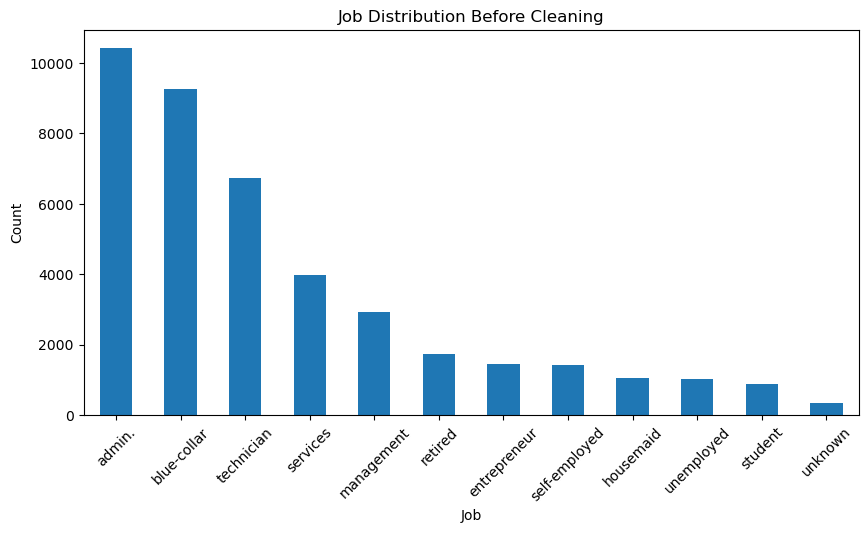

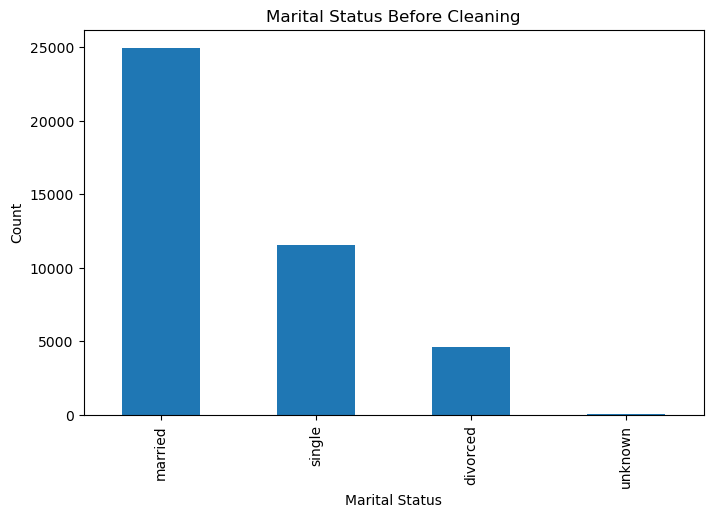

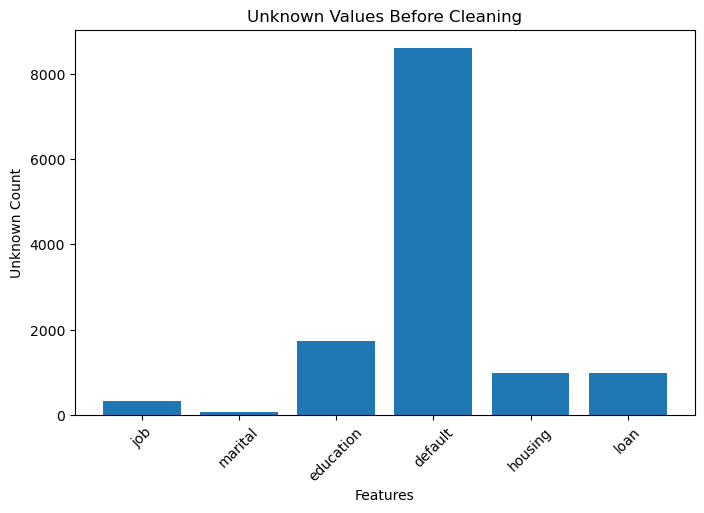

In [19]:
# Graph1 : Job Distribution
plt.figure(figsize=(10,5))
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution Before Cleaning")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Graph2 : Marital Distribution
plt.figure(figsize=(8,5))
df["marital"].value_counts().plot(kind="bar")
plt.title("Marital Status Before Cleaning")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

#Graph3 : Unknown Value Distribution
unknown_counts = unknown_summary[unknown_summary["Unknown Values"]>0]

plt.figure(figsize=(8,5))
plt.bar(unknown_counts.index, unknown_counts["Unknown Values"])
plt.title("Unknown Values Before Cleaning")
plt.xlabel("Features")
plt.ylabel("Unknown Count")
plt.xticks(rotation=45)
plt.show()

#### Cleaning Decision Reasoning

##### 1. Low-Percentage Missing Data (< 1%)
* **`job`**: Contains 330 unknown values (0.80%).
* **`marital`**: Contains 80 unknown values (0.19%).
* **Action**: **Remove these records.**
* **Rationale**: Because these missing values constitute less than 1% of the dataset, dropping them yields a negligible impact on overall sample size while immediately improving data quality.

##### 2. High-Percentage Missing Data (> 1%)
* **`education`**: 4.20% unknown values.
* **`housing`**: 2.40% unknown values.
* **`loan`**: 2.40% unknown values.
* **`default`**: 20.87% unknown values.
* **Action**: **Retain "unknown" values** as a distinct, separate category.
* **Rationale**: Removing these rows would cause significant data loss—particularly within the `default` column. Keeping them as a valid category preserves the dataset's integrity.


#### Cleaning

In [20]:
df = df[df["job"]!="unknown"]
df = df[df["marital"]!="unknown"]

# Dataset shape after cleaning
after_shape = df.shape

print("Shape After Cleaning :", after_shape)
print("Rows Removed :", before_shape[0]-after_shape[0])

# Verification
unknown_summary_after = pd.DataFrame({
    "Unknown Values":[(df[col]=="unknown").sum() for col in categorical_columns],
    "Percentage (%)":[((df[col]=="unknown").sum()/len(df))*100 for col in categorical_columns]
},index=categorical_columns)

unknown_summary_after

Shape After Cleaning : (40787, 21)
Rows Removed : 401


,Unknown Values,Percentage (%)
job,0,0.000000
marital,0,0.000000
education,1596,3.913011
default,8436,20.683061
housing,984,2.412533
loan,984,2.412533
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000
poutcome,0,0.000000


#### Graphical Analysis (After Cleaning)

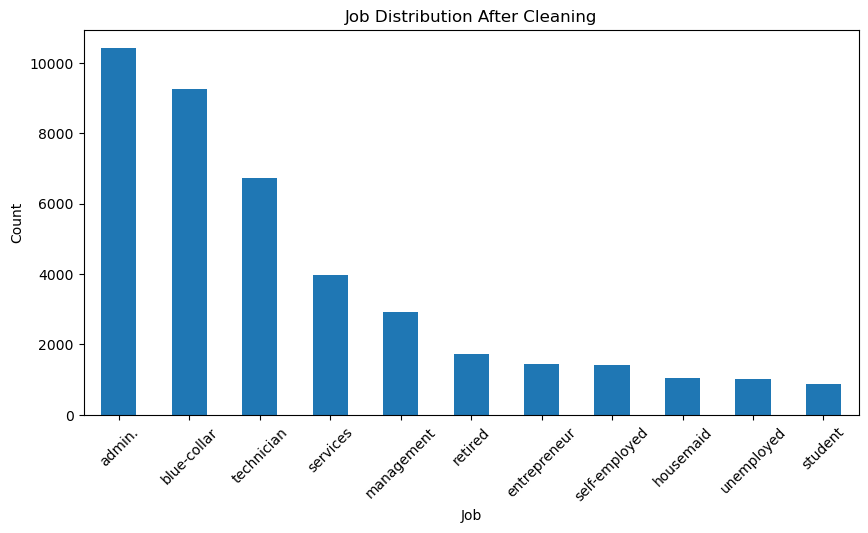

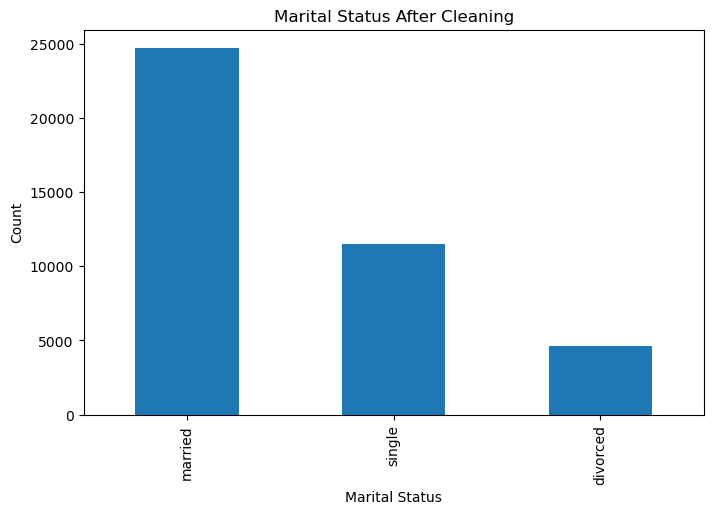

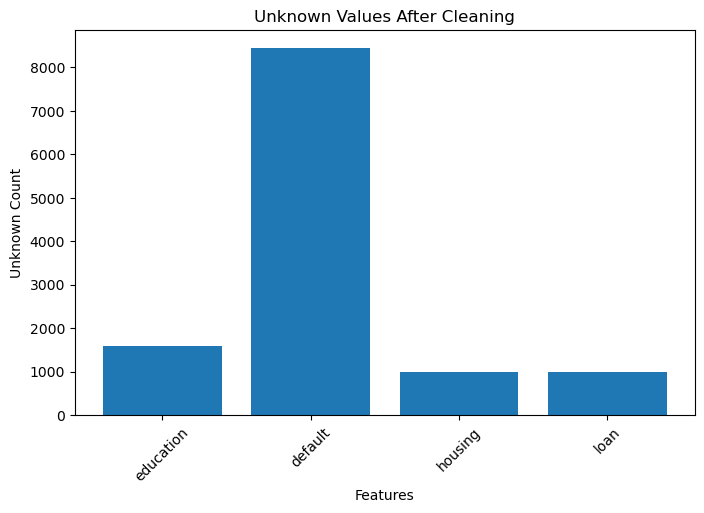

In [21]:
# Graph1 : Job Distribution
plt.figure(figsize=(10,5))
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution After Cleaning")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Graph2 : Marital Distribution
plt.figure(figsize=(8,5))
df["marital"].value_counts().plot(kind="bar")
plt.title("Marital Status After Cleaning")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

#Graph3 : Unknown Value Distribution
unknown_counts_after = unknown_summary_after[unknown_summary_after["Unknown Values"]>0]

plt.figure(figsize=(8,5))
plt.bar(unknown_counts_after.index, unknown_counts_after["Unknown Values"])
plt.title("Unknown Values After Cleaning")
plt.xlabel("Features")
plt.ylabel("Unknown Count")
plt.xticks(rotation=45)
plt.show()

#### Conclusion :
- The dataset was examined for categorical values represented as "unknown". 
- The dataset initially contained 330 records with unknown values in the job column and 80 records in the marital column.
- Since the job (0.80%) and marital (0.19%) columns contained only a very small proportion of unknown values, the corresponding records were removed. 
- This resulted in minimal data loss while improving data quality. 
- For the education, housing, loan, and default columns, the "unknown" category was retained because removing these records would have caused a significant reduction in the dataset, particularly for the default feature where over 20% of observations contained unknown values.

### Step 3: Duplicate Record Handling

#### Objective:
- To identify and remove duplicate records from the dataset to ensure that each observation is unique, thereby preventing redundancy and reducing the risk of biased statistical analysis and machine learning model performance

In [22]:
print("Dataset Shape:", df.shape)

Dataset Shape: (40787, 21)


In [23]:
duplicate_count = df.duplicated().sum()

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Records : {duplicate_count}")
print(f"Percentage        : {duplicate_percentage:.4f}%")

Duplicate Records : 12
Percentage        : 0.0294%


In [24]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [25]:
before_shape = df.shape

print("Shape Before Cleaning:", before_shape)

Shape Before Cleaning: (40787, 21)


#### Graphical Analysis (Before)

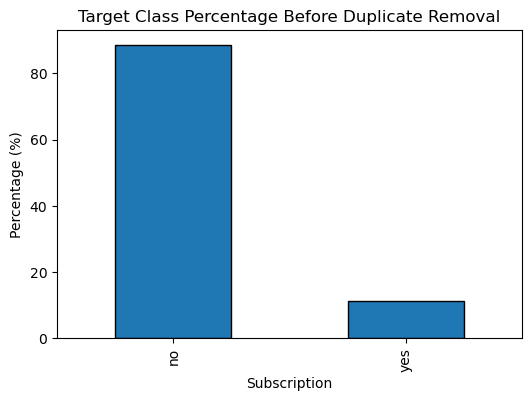

In [26]:
target_before = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(6,4))
target_before.plot(kind="bar", edgecolor="black")

plt.title("Target Class Percentage Before Duplicate Removal")
plt.xlabel("Subscription")
plt.ylabel("Percentage (%)")

plt.show()

#### Handling

In [27]:
# Handling
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"{duplicate_count} duplicate records removed successfully.")
else:
    print("No duplicate records found. Dataset remains unchanged.")

# Shape after handling
after_shape = df.shape

print("Dataset Shape After Cleaning:", after_shape)
print("Rows Removed:", before_shape[0] - after_shape[0])

# Verification
print("Duplicate Records Remaining:", df.duplicated().sum())

12 duplicate records removed successfully.
Dataset Shape After Cleaning: (40775, 21)
Rows Removed: 12
Duplicate Records Remaining: 0


#### Graphical Analysis (After)

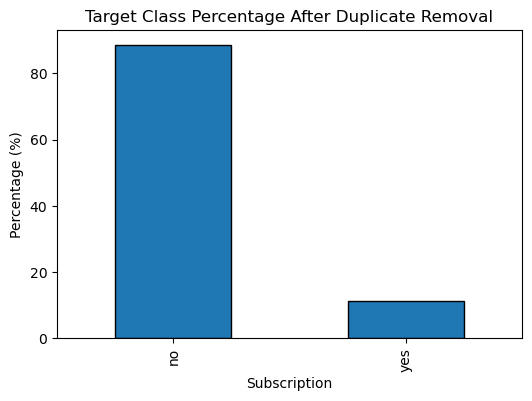

In [28]:
target_after = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(6,4))
target_after.plot(kind="bar", edgecolor="black")

plt.title("Target Class Percentage After Duplicate Removal")
plt.xlabel("Subscription")
plt.ylabel("Percentage (%)")

plt.show()

#### Conclusion : 
- A total of 12 duplicate records were identified and removed from the dataset. The dataset size decreased from (40787, 21)
 to (40775, 21) observations. 
- Comparison of the target variable distribution before and after duplicate removal indicated that the class distribution was preserved.

### Step 4: Outlier Detection And Treatment

#### Objective:
- To identify and appropriately handle extreme values in numerical features that may adversely affect statistical analysis and machine learning model performance while preserving valid observations.

#### Statistical Analysis

In [29]:
# Current Dataset Shape
print("Current Dataset Shape: ", df.shape)

# Identifying Numerical Features
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical Features : ")
print(numerical_columns.tolist())

Current Dataset Shape:  (40775, 21)
Numerical Features : 
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


#### 1. Age
- To identify and evaluate extreme age values and determine whether they should be retained or treated.

##### Statistical Analysis

In [30]:
df["age"].describe()

count    40775.000000
mean        39.978541
std         10.401573
min         17.000000
25%         32.000000
50%         38.000000
75%         47.000000
max         98.000000
Name: age, dtype: float64

##### Dataset Shape (Before)

In [31]:
before_shape = df.shape
print("Dataset Shape: ", before_shape)

Dataset Shape:  (40775, 21)


##### Graphical Analysis (Before)

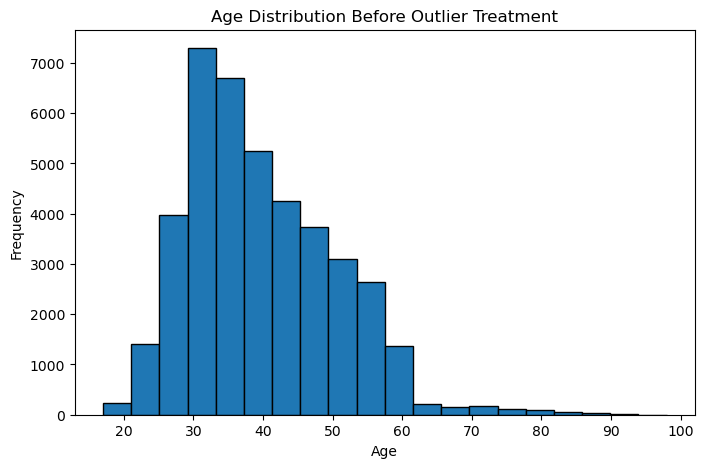

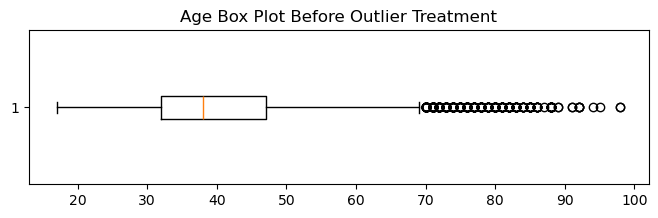

In [32]:
#Frequency Analysis
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Age Distribution Before Outlier Treatment")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


# Outlier Observation
plt.figure(figsize=(8,2))

plt.boxplot(df["age"], vert=False)

plt.title("Age Box Plot Before Outlier Treatment")

plt.show()

##### Outlier Observation and Prediction

In [33]:
# Detect Ouliers
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

# Count Outliers
age_outliers = df[
    (df["age"] < lower) |
    (df["age"] > upper)
]

print("Number of Outliers:", len(age_outliers))

#Percentage of Outliers
age_outlier_percentage = (len(age_outliers) / len(df)) * 100

print(f"Age Outliers: {len(age_outliers)}")
print(f"Percentage: {age_outlier_percentage:.2f}%")

age_outliers.head()

Lower Bound: 9.5
Upper Bound: 69.5
Number of Outliers: 462
Age Outliers: 462
Percentage: 1.13%


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
27713,70,retired,divorced,basic.4y,no,yes,no,cellular,mar,mon,...,3,999,0,nonexistent,-1.8,92.843,-50.0,1.811,5099.1,yes
27757,76,retired,married,university.degree,no,no,yes,cellular,mar,thu,...,9,999,0,nonexistent,-1.8,92.843,-50.0,1.757,5099.1,no
27780,73,retired,married,university.degree,no,yes,no,cellular,mar,tue,...,1,999,1,failure,-1.8,92.843,-50.0,1.687,5099.1,no
27800,88,retired,divorced,basic.4y,no,yes,no,cellular,mar,wed,...,1,999,0,nonexistent,-1.8,92.843,-50.0,1.663,5099.1,no
27802,88,retired,divorced,basic.4y,no,no,no,cellular,mar,wed,...,2,999,0,nonexistent,-1.8,92.843,-50.0,1.663,5099.1,yes


##### Cleaning Operation

In [34]:
print("No outlier treatment was performed for the Age feature.")
print("Reason: The detected outliers represent valid customer ages and are important for model learning.")

No outlier treatment was performed for the Age feature.
Reason: The detected outliers represent valid customer ages and are important for model learning.


##### Dataset Shape After Cleaning

In [35]:
after_shape = df.shape

print("Dataset Shape After Analysis:", after_shape)

Dataset Shape After Analysis: (40775, 21)


##### Age Outlier Analysis
-  Analysis
    - The histogram indicates that the **age** feature is positively (right) skewed, with the majority of customers belonging to the age group of **30 to 50 years**.
    - The box plot identifies observations above **69.5 years** as statistical outliers according to the IQR method.
    - A total of **462 observations** were detected as outliers, representing approximately **1.13%** of the dataset.
    - Examination of these observations shows that the ages range from around **70 to 98 years**, which are realistic values for bank customers and do not indicate data entry errors.
- Outlier Treatment Decision
    - Although the IQR method identified 462 observations as outliers, these values represent **valid customer ages** rather than incorrect or inconsistent data. 
    - Elderly customers form an important customer segment in banking, and removing them could reduce the model's ability to learn patterns associated with this group. 
    - Therefore, **no outlier treatment was performed**, and all observations were retained.

##### Conclusion:
- Using the IQR method, 462 observations (approximately X%) were identified as statistical outliers in the age feature. 
- These values correspond to elderly customers and represent valid observations rather than data entry errors. 
- Since removing them would reduce the representation of older customers and potentially introduce bias into the predictive model, no outlier treatment was performed. 
- Consequently, the dataset remained unchanged.

#### 2. Duration
- To identify extreme values in the duration feature and determine whether they represent genuine customer interactions or require outlier treatment.

##### Statistical Analysis

In [36]:
df["duration"].describe()

count    40775.000000
mean       258.360932
std        259.295917
min          0.000000
25%        102.000000
50%        180.000000
75%        320.000000
max       4918.000000
Name: duration, dtype: float64

##### Dataset Shape (Before)

In [37]:
print("Current Datasety Shape: ", df.shape)

Current Datasety Shape:  (40775, 21)


##### Graphical Analysis (Before)

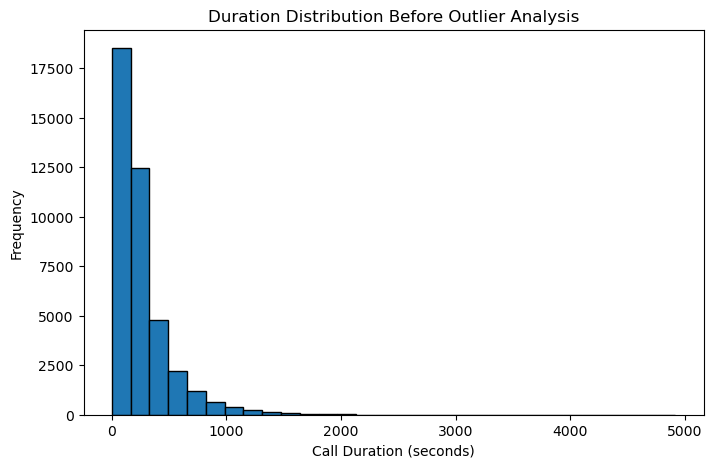

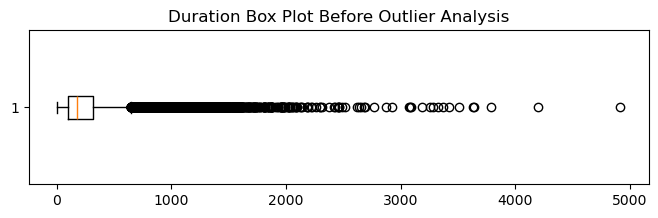

In [38]:
# Frequency Analysis
plt.figure(figsize=(8,5))

plt.hist(df["duration"], bins=30, edgecolor="black")

plt.title("Duration Distribution Before Outlier Analysis")
plt.xlabel("Call Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

# Outlier Observation
plt.figure(figsize=(8,2))

plt.boxplot(df["duration"], vert=False)

plt.title("Duration Box Plot Before Outlier Analysis")

plt.show()

##### Outlier Observation and Handling

In [39]:
# Detect Outliers
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

# Count Outliers
duration_outliers = df[
    (df["duration"] < lower) |
    (df["duration"] > upper)
]

print("Number of Outliers:", len(duration_outliers))
print("Percentage:",
      round(len(duration_outliers) / len(df) * 100, 2), "%")

duration_outliers.head()

Lower Bound: -225.0
Upper Bound: 647.0
Number of Outliers: 2913
Percentage: 7.14 %


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
37,52,technician,married,basic.9y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
57,45,services,married,high.school,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
61,51,blue-collar,married,basic.9y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
75,41,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
83,49,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes


##### Duration Outlier Analysis
- Analysis
    - The histogram shows that the **duration** feature is highly positively (right) skewed, with most phone calls lasting less than **500 seconds**.
    - The box plot identifies observations above **647 seconds** as statistical outliers using the IQR method.
    - A total of **2913 observations** were detected as outliers, representing approximately **7.14%** of the dataset.
    - These observations correspond to longer customer conversations and reflect the natural variation in call durations rather than erroneous values.
- Outlier Treatment Decision
    - Although the IQR method detected 2913 observations as outliers, these values represent **genuine customer call durations** rather than data anomalies. 
    - Longer conversations are expected in telemarketing campaigns and may contain valuable information for predicting customer subscription behavior. 
    - Removing or capping these values could result in the loss of important business information. 
    - Therefore, **no outlier treatment was performed**, and all observations were retained.

##### Cleaning Operation

In [40]:
print("No outlier treatment was performed for the 'duration' feature.")
print("Reason: Long call durations are valid observations and contain important information for model learning.")

No outlier treatment was performed for the 'duration' feature.
Reason: Long call durations are valid observations and contain important information for model learning.


##### Dataset Shape After Analysis

In [41]:
print("Dataset Shape After Analysis:", df.shape)

Dataset Shape After Analysis: (40775, 21)


##### Conclusion
- Using the IQR method, 2913 observations (7.14%) were identified as statistical outliers in the duration feature. 
- However, these values represent genuine variations in customer call duration rather than erroneous entries. 
- Since long-duration calls are meaningful and may contribute valuable information for predictive modeling, no outlier treatment was performed.
- Consequently, the dataset remained unchanged.

#### 3. Campaign
- To identify extreme values in the campaign feature and determine whether they represent valid marketing activities or require outlier treatment.

##### Statistical Analysis

In [42]:
df["campaign"].describe()

count    40775.000000
mean         2.566401
std          2.768411
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

##### Dataset Shape

In [43]:
print("Current Dataset Shape: ", df.shape)

Current Dataset Shape:  (40775, 21)


##### Graphical Analysis (Before)

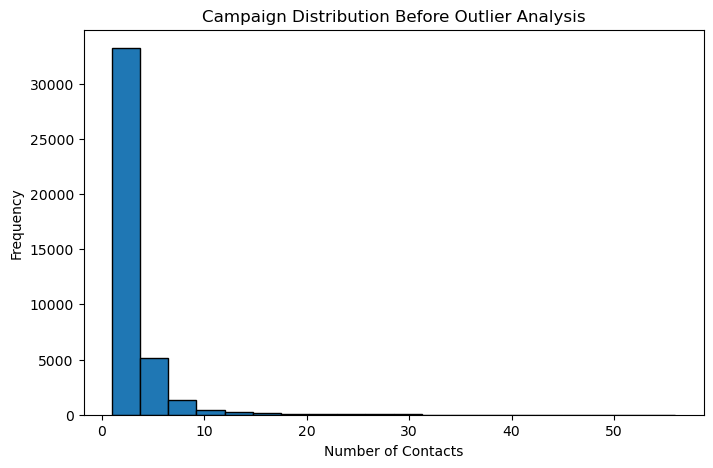

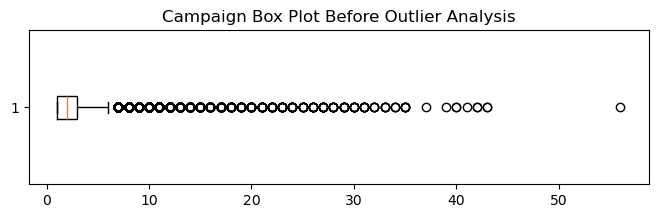

In [44]:
# Frequency Analysis
plt.figure(figsize=(8,5))

plt.hist(df["campaign"], bins=20, edgecolor="black")

plt.title("Campaign Distribution Before Outlier Analysis")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")

plt.show()

# Outlier Observations
plt.figure(figsize=(8,2))

plt.boxplot(df["campaign"], vert=False)

plt.title("Campaign Box Plot Before Outlier Analysis")

plt.show()

##### Outlier Observation and Handling

In [45]:
# Detect Outliers
Q1 = df["campaign"].quantile(0.25)
Q3 = df["campaign"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

#Count Outliers
campaign_outliers = df[
    (df["campaign"] < lower) |
    (df["campaign"] > upper)
]

print("Number of Outliers:", len(campaign_outliers))
print("Percentage:",
      round(len(campaign_outliers) / len(df) * 100, 2), "%")

campaign_outliers.head()

Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 2372
Percentage: 5.82 %


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
887,54,admin.,married,university.degree,no,no,no,telephone,may,wed,...,7,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
1043,41,technician,single,university.degree,unknown,no,no,telephone,may,wed,...,8,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
1094,40,technician,married,professional.course,no,yes,no,telephone,may,wed,...,8,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
1097,51,blue-collar,married,basic.4y,unknown,yes,no,telephone,may,wed,...,7,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
1230,48,blue-collar,divorced,basic.4y,no,no,no,telephone,may,thu,...,7,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


##### Campaign Outlier Analysis
- Analysis
    - The histogram shows that the **campaign** feature is highly positively (right) skewed, with most customers being contacted between **1 and 5 times** during the marketing campaign.
    - The box plot identifies observations above **6 contacts** as statistical outliers according to the IQR method.
    - A total of **2372 observations** were detected as outliers, representing approximately **5.82%** of the dataset.
    - These observations correspond to customers who received a higher number of contact attempts and reflect genuine marketing activities rather than incorrect or inconsistent data.
- Outlier Treatment Decision
    - Although the IQR method identified 2372 observations as outliers, these values represent **valid customer contact frequencies** rather than data errors. 
    - Customers may require multiple contact attempts before making a decision, making higher campaign values a natural part of telemarketing campaigns.
    - Removing or capping these observations could eliminate valuable business information and negatively affect the model's learning process.
    - Therefore, **no outlier treatment was performed**, and all observations were retained.
- Overall Outlier Analysis Conclusion
    - Outlier analysis was performed on the **age**, **duration**, and **campaign** features using the Interquartile Range (IQR) method.
    -  Although statistical outliers were detected in all three features, detailed analysis showed that these observations represent **valid real-world customer and marketing characteristics** rather than erroneous data.
    -  Therefore, no outlier treatment was performed.
    - Retaining these observations helps preserve important information and prevents unnecessary loss of data that could impact the predictive performance of the machine learning model.

##### Cleaning Operation

In [46]:
print("No outlier treatment was performed for the 'duration' feature.")
print("Reason: Long call durations are valid observations and contain important information for model learning.")

No outlier treatment was performed for the 'duration' feature.
Reason: Long call durations are valid observations and contain important information for model learning.


##### Dataset Shape After Analysis

In [47]:
print("Dataset Shape After Analysis:", df.shape)

Dataset Shape After Analysis: (40775, 21)


##### Conclusion
- Using the IQR method, **2372 observations (5.82%)** were identified as statistical outliers in the `campaign` feature.
- However, these values represent genuine customer contact frequencies during the marketing campaign rather than erroneous or inconsistent data.
- Customers may require multiple contact attempts before making a decision, making higher campaign values a natural part of the business process.
- Therefore, no outlier treatment was performed, and all observations were retained to preserve valuable information for predictive modeling.

### Step 5: Data Type Verification

#### Objective
- To verify that each feature has the appropriate data type required for preprocessing and machine learning. Ensuring correct data types helps prevent errors during encoding, scaling, and model training.

#### Statistical Analysis

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40775 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40775 non-null  int64  
 1   job             40775 non-null  object 
 2   marital         40775 non-null  object 
 3   education       40775 non-null  object 
 4   default         40775 non-null  object 
 5   housing         40775 non-null  object 
 6   loan            40775 non-null  object 
 7   contact         40775 non-null  object 
 8   month           40775 non-null  object 
 9   day_of_week     40775 non-null  object 
 10  duration        40775 non-null  int64  
 11  campaign        40775 non-null  int64  
 12  pdays           40775 non-null  int64  
 13  previous        40775 non-null  int64  
 14  poutcome        40775 non-null  object 
 15  emp.var.rate    40775 non-null  float64
 16  cons.price.idx  40775 non-null  float64
 17  cons.conf.idx   40775 non-null  floa

#### Display Datatypes

In [49]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

#### Check for incorrect datatypes

In [50]:
print(df.select_dtypes(include="object").columns.tolist())
print(df.select_dtypes(include=["int64", "float64"]).columns.to_list())

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


#### Cleaning Operation

In [51]:
print("No data type conversion was required.")
print("All features already have appropriate data types.")

No data type conversion was required.
All features already have appropriate data types.


#### Dataset Shape After Verification

In [52]:
print("Dataset Shape: ", df.shape)

Dataset Shape:  (40775, 21)


#### Conclusion
- The data types of all features were verified before proceeding with further preprocessing.
- All categorical variables were correctly stored as object data types, while numerical variables were stored as integer or floating-point data types.
- Since no inconsistencies were found, no data type conversion was required, and the dataset was considered ready for categorical encoding and feature scaling.

## Section 3: Feature Engineering
### Objective
- Since machine learning models cannot work directly with categorical variables, we need to convert them into numerical form.
- Feature engineering transforms the cleaned data into a machine-learning-ready format by converting categorical variables into numerical representations and scaling numerical features where required.

In [53]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Features:")
print(categorical_columns.tolist())

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [54]:
encoding_strategy = pd.DataFrame({
    "Feature": [
        "job",
        "marital",
        "education",
        "default",
        "housing",
        "loan",
        "contact",
        "month",
        "day_of_week",
        "poutcome",
        "y"
    ],
    
    "Variable Type": [
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Categorical (Binary)",
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Categorical (Nominal)",
        "Target (Binary)"
    ],
    
    "Recommended Encoding": [
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "Label Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "Label Encoding"
    ],
    
    "Reason": [
        "No natural order among job categories.",
        "No natural order among marital status categories.",
        "Avoids imposing an artificial order on education levels.",
        "Contains 'yes', 'no', and 'unknown'; preserves all categories.",
        "Contains 'yes', 'no', and 'unknown'; preserves all categories.",
        "Contains 'yes', 'no', and 'unknown'; preserves all categories.",
        "Binary feature with two categories (telephone/cellular).",
        "Months are treated as independent categorical values for prediction.",
        "Weekdays have no meaningful ranking for prediction.",
        "Previous campaign outcomes are independent categories.",
        "Binary target variable for classification."
    ]
})

encoding_strategy

,Feature,Variable Type,Recommended Encoding,Reason
0,job,Categorical (Nominal),One-Hot Encoding,No natural order among job categories.
1,marital,Categorical (Nominal),One-Hot Encoding,No natural order among marital status categories.
2,education,Categorical (Nominal),One-Hot Encoding,Avoids imposing an artificial order on educati...
3,default,Categorical (Nominal),One-Hot Encoding,"Contains 'yes', 'no', and 'unknown'; preserves..."
4,housing,Categorical (Nominal),One-Hot Encoding,"Contains 'yes', 'no', and 'unknown'; preserves..."
5,loan,Categorical (Nominal),One-Hot Encoding,"Contains 'yes', 'no', and 'unknown'; preserves..."
6,contact,Categorical (Binary),Label Encoding,Binary feature with two categories (telephone/...
7,month,Categorical (Nominal),One-Hot Encoding,Months are treated as independent categorical ...
8,day_of_week,Categorical (Nominal),One-Hot Encoding,Weekdays have no meaningful ranking for predic...
9,poutcome,Categorical (Nominal),One-Hot Encoding,Previous campaign outcomes are independent cat...


### 1. Feature Encoding
#### Objective 
- Convert categorical variables into numerical representations so that they can be processed by machine learning algorithms while preserving the information contained in each feature.

#### Statistical Analysis

In [55]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns)
print(f"Number of Categorical Columns: {len(categorical_columns)}")

Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')
Number of Categorical Columns: 11


In [56]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'entrepreneur' 'student']

marital
['married' 'single' 'divorced']

education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

default
['no' 'unknown' 'yes']

housing
['no' 'yes' 'unknown']

loan
['no' 'yes' 'unknown']

contact
['telephone' 'cellular']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']

poutcome
['nonexistent' 'failure' 'success']

y
['no' 'yes']


In [57]:
print("Shape Before Encoding:", df.shape)

Shape Before Encoding: (40775, 21)


#### 1. Label Encoding for Binary Variables

In [58]:
df["contact"] = df["contact"].map({
    "telephone": 0,
    "cellular": 1
})

df["y"] = df["y"].map({
    "no": 0,
    "yes": 1
})

#### 2. One-Hot Encoding
-  One-Hot Encoding is a data preprocessing technique used to convert categorical data (like text or labels) into a numerical format that machine learning models can understand

In [59]:
nominal_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "month",
    "day_of_week",
    "poutcome"
]

df = pd.get_dummies(
    df,
    columns=nominal_columns,
    dtype=int
)

In [60]:
print("Shape After Encoding:", df.shape)

Shape After Encoding: (40775, 61)


#### Verification

In [61]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40775 entries, 0 to 41187
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            40775 non-null  int64  
 1   contact                        40775 non-null  int64  
 2   duration                       40775 non-null  int64  
 3   campaign                       40775 non-null  int64  
 4   pdays                          40775 non-null  int64  
 5   previous                       40775 non-null  int64  
 6   emp.var.rate                   40775 non-null  float64
 7   cons.price.idx                 40775 non-null  float64
 8   cons.conf.idx                  40775 non-null  float64
 9   euribor3m                      40775 non-null  float64
 10  nr.employed                    40775 non-null  float64
 11  y                              40775 non-null  int64  
 12  job_admin.                     40775 non-null  int6

In [62]:
print(df.dtypes)

age                     int64
contact                 int64
duration                int64
campaign                int64
pdays                   int64
                        ...  
day_of_week_tue         int64
day_of_week_wed         int64
poutcome_failure        int64
poutcome_nonexistent    int64
poutcome_success        int64
Length: 61, dtype: object


In [63]:
print("Number of Features After Encoding:", df.shape[1])

Number of Features After Encoding: 61


In [64]:
print("Remaining Object Columns:")
print(df.select_dtypes(include="object").columns.tolist())

Remaining Object Columns:
[]


In [65]:
df

,age,contact,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,0,261,1,999,0,1.1,93.994,-36.4,4.857,...,0,0,0,1,0,0,0,0,1,0
1,57,0,149,1,999,0,1.1,93.994,-36.4,4.857,...,0,0,0,1,0,0,0,0,1,0
2,37,0,226,1,999,0,1.1,93.994,-36.4,4.857,...,0,0,0,1,0,0,0,0,1,0
3,40,0,151,1,999,0,1.1,93.994,-36.4,4.857,...,0,0,0,1,0,0,0,0,1,0
4,56,0,307,1,999,0,1.1,93.994,-36.4,4.857,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,334,1,999,0,-1.1,94.767,-50.8,1.028,...,0,0,1,0,0,0,0,0,1,0
41184,46,1,383,1,999,0,-1.1,94.767,-50.8,1.028,...,0,0,1,0,0,0,0,0,1,0
41185,56,1,189,2,999,0,-1.1,94.767,-50.8,1.028,...,0,0,1,0,0,0,0,0,1,0
41186,44,1,442,1,999,0,-1.1,94.767,-50.8,1.028,...,0,0,1,0,0,0,0,0,1,0


#### Conclusion
- Binary categorical features (default, housing, loan, contact, and y) were converted using manual label encoding, while nominal categorical features (job, marital, education, month, day_of_week, and poutcome) were transformed using One-Hot Encoding.
- All categories were retained during encoding to preserve complete information for model training.
- After encoding, the dataset contained only numerical features and was ready for feature scaling and subsequent machine learning tasks.

# Section 4: Model Preparation

Although the duration feature contained valid values, it will be removed before model training because it is only known after the marketing call has been completed. Including this feature would introduce data leakage, resulting in overly optimistic model performance that would not be applicable in real-world prediction scenarios.


### Step 1: Creating X and y

In [66]:
df = df.drop(columns=["duration"])

In [67]:
# Separating target column from dataset
X = df.drop("y", axis=1)

# Extract y (target column) from dataset
y = df["y"]

#### Verify Split:

In [68]:
print(X.shape)
print(y.shape)

(40775, 59)
(40775,)


#### Check target values:

In [69]:
print(y.value_counts())

y
0    36182
1     4593
Name: count, dtype: int64


#### Conclusion:
- Target Variable Distribution:
    - The target variable is imbalanced. 
    - Approximately 88.74% of customers did not subscribe to the term deposit, while only 11.26% subscribed. 
    - This indicates that the dataset is skewed toward the majority class. 
    - Therefore, model evaluation should not rely solely on accuracy; additional metrics such as Precision, Recall, F1-Score, and ROC-AUC should also be considered to assess performance effectively.

## Step 2: Train-Test Split

In [70]:
# Importing function needed to split dataset
from sklearn.model_selection import train_test_split

# Performing split
# X -> input features 
# y -> target variable
# test size = 0.2 => 20% testing data, 80% training data
# random state=42 -> gives the same data split for every code run
# stratify=y -> Your target distribution is: No  = 88.74% & Yes = 11.26% => Without stratify, the split could accidentally create an uneven distribution. With stratify=y, both sets have even distribution even though we have an imbalanced dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify split
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (32620, 59)
Testing Features: (8155, 59)
Training Target: (32620,)
Testing Target: (8155,)


In [71]:
# Checking class Distribution
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
0    0.88737
1    0.11263
Name: proportion, dtype: float64
y
0    0.887308
1    0.112692
Name: proportion, dtype: float64


### Conclusion:
- The dataset was divided into training and testing sets using an 80:20 ratio. 
- Since the target variable was imbalanced, stratified sampling was applied to preserve the original class distribution in both subsets.
- A fixed random_state of 42 was used to ensure reproducibility of the results.

### 3. Feature Selection
#### Objective
- To evaluate the relevance of the encoded features and determine whether any features should be removed before model training. Feature selection helps reduce redundancy, improve model interpretability, and potentially enhance predictive performance.

#### Statistical Analysis

In [72]:
print("Number of Features :", df.shape[1]-1)   # excluding target
print("Target Variable :", "y")

Number of Features : 59
Target Variable : y


In [73]:
X = df.drop("y", axis=1)
y = df["y"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (40775, 59)
Target Shape : (40775,)


#### 1. Correlation Analysis

In [74]:
numerical_features = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

corr_matrix = df[numerical_features].corr()
corr_matrix

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.003414,-0.034230,0.024465,-0.000586,0.000159,0.127881,0.010448,-0.017610
campaign,0.003414,1.000000,0.052371,-0.078932,0.150160,0.127052,-0.013229,0.134621,0.143470
pdays,-0.034230,0.052371,1.000000,-0.586168,0.269956,0.078485,-0.092240,0.295609,0.371244
previous,0.024465,-0.078932,-0.586168,1.000000,-0.419486,-0.202290,-0.051704,-0.453549,-0.500352
emp.var.rate,-0.000586,0.150160,0.269956,-0.419486,1.000000,0.775292,0.198133,0.972231,0.906802
cons.price.idx,0.000159,0.127052,0.078485,-0.202290,0.775292,1.000000,0.061180,0.687997,0.521496
cons.conf.idx,0.127881,-0.013229,-0.092240,-0.051704,0.198133,0.061180,1.000000,0.279367,0.102142
euribor3m,0.010448,0.134621,0.295609,-0.453549,0.972231,0.687997,0.279367,1.000000,0.945131
nr.employed,-0.017610,0.143470,0.371244,-0.500352,0.906802,0.521496,0.102142,0.945131,1.000000


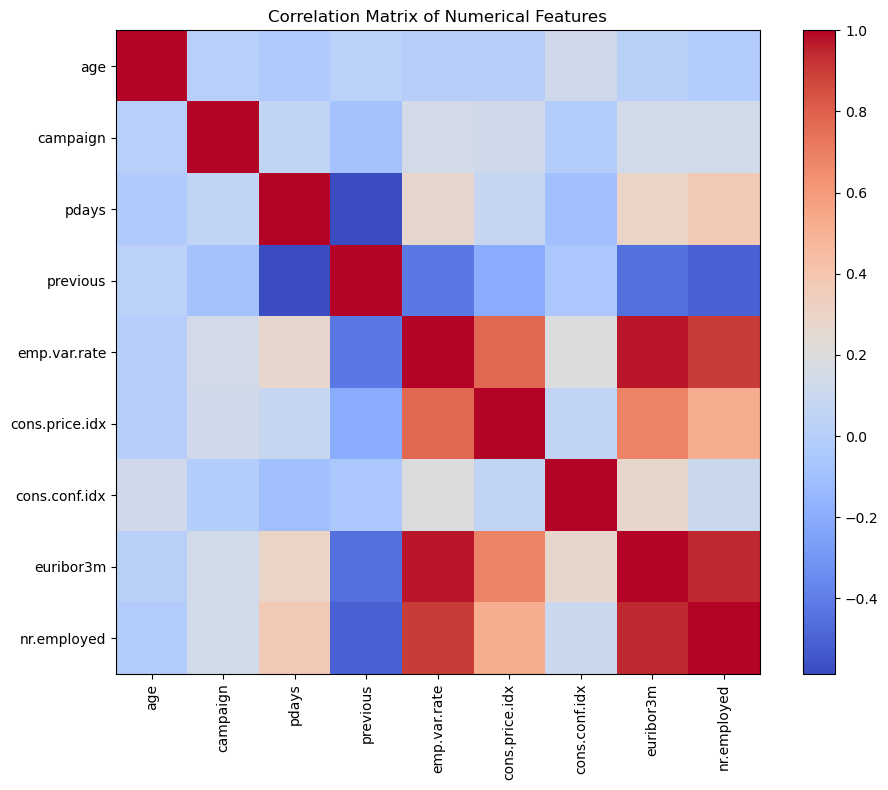

In [75]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [76]:
threshold = 0.8

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr)

high_corr_df

,Feature 1,Feature 2,Correlation
0,euribor3m,emp.var.rate,0.972231
1,nr.employed,emp.var.rate,0.906802
2,nr.employed,euribor3m,0.945131


##### Conclusion
- Correlation analysis identified strong positive relationships among emp.var.rate, euribor3m, and nr.employed, with correlation coefficients greater than 0.90.
- These features represent related macroeconomic indicators and therefore exhibit expected correlation.
- However, no features were removed at this stage, as correlation alone does not determine feature importance.
- The final decision will be based on feature importance analysis during the next step.

## Step 3: Feature Scaling(Standard Scaler)

Machine learning algorithms such as Logistic Regression perform better when the input features are on a similar scale.

Since the dataset contains numerical features with different ranges, StandardScaler is used to standardize the feature values.

The scaler is fitted only on the training data to prevent data leakage. The same transformation is then applied to the testing data.

In [77]:
numerical_columns = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

numerical_columns

['age',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

### Step 1: Import StandardScaler
- StandardScaler is a preprocessing tool from scikit-learn that standardizes numerical features so they have:
1. Mean ≈ 0
2. Standard Deviation ≈ 1
<br>
- This helps algorithms like Logistic Regression converge faster and prevents features with large values from dominating the optimization.

In [78]:
from sklearn.preprocessing import StandardScaler

### Step 2: Create the Scaler

Right now, scaler = StandardScaler() scales nothing. It just creates a scaler object that is ready to learn : 
1. mean of each feature
2. standard deviation of each feature

In [79]:
scaler = StandardScaler()

### Step 3: Fit and Transform the data

1. fit() => The scaler looks at the training data and calculates, for every one of the 59 features:
<br>
        - Mean (μ)
        <br>
        - Standard Deviation (σ)
        <br>
        eg : for every row of age, there is stored a mean and standard deviation. Similarly for every row in column, there is different mean and standard deviation stored.
2. transform() => Now that it knows the mean and standard deviation, it transforms every value using those statistics.

In [80]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [81]:
X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

- Notice there's no fit() when scaling test data. We reuse the same mean and standard deviation learned from the training set to scale the test set to prevent data leakage.
-  Because if we fit the data, then the model will know the mean and standard deviation of the testing data beforehand.
- Thus, we use directly tranform to scale the test data using statistics from training data.
- This simulates how the model will work in the real world, where new customer data is transformed using the same scaler that was learned during training.

In [82]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


Thus, StandardScaler returns a NumPy array, not a DataFrame as Scikit-learn is built around NumPy arrays because:
- They are faster for numerical computations.
- Machine learning algorithms operate on numbers, not DataFrame formatting.
- Column names and indices are not required for training.
- So during scaling, Pandas metadata (column names and index) is removed.
- If we had done X_train_Scaled = scaler.fit_transform(X_train) and then print(type(X_train_Scaled)) => it would return a numpy array.
- Now, notice the left-hand side of our code. We are not replacing X_train. We are replacing only a few columns inside X_train.
- Hence, print(type(X_train)) => gives pandas dataframe class.


In [83]:
print(X_train[numerical_columns].describe())

                age      campaign         pdays      previous  emp.var.rate  \
count  3.262000e+04  32620.000000  3.262000e+04  3.262000e+04  3.262000e+04   
mean   1.437640e-17      0.000000 -2.570326e-16  6.414924e-17  2.526761e-17   
std    1.000015e+00      1.000015  1.000015e+00  1.000015e+00  1.000015e+00   
min   -2.200388e+00     -0.567908 -5.092308e+00 -3.523423e-01 -2.214421e+00   
25%   -7.633085e-01     -0.567908  1.976144e-01 -3.523423e-01 -1.195916e+00   
50%   -1.884768e-01     -0.205657  1.976144e-01 -3.523423e-01  6.501244e-01   
75%    6.737708e-01      0.156594  1.976144e-01 -3.523423e-01  8.410941e-01   
max    5.559841e+00     14.646628  1.976144e-01  1.173326e+01  8.410941e-01   

       cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count    3.262000e+04   3.262000e+04  3.262000e+04  3.262000e+04  
mean     2.037223e-14   2.208738e-16 -2.387354e-16 -2.922330e-15  
std      1.000015e+00   1.000015e+00  1.000015e+00  1.000015e+00  
min     -2.373799e+0

In [84]:
print(X_train.columns.tolist())

['age', 'contact', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome_nonexistent', 'poutcome_success

In [85]:
print(df["contact"].unique())
print(df["contact"].dtype)

[0 1]
int64


In [86]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

y_test.to_csv("y_test.csv", index=False)

In [87]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [88]:
print("Number of features:", X_train.shape[1])

print("\nFinal feature columns:")
print(X_train.columns.tolist())

Number of features: 59

Final feature columns:
['age', 'contact', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_fail

In [89]:
print(numerical_columns)

['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
